In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the stock universe
stocks = pd.read_csv(r'C:\Users\siraa\Desktop\nse-sharia-screener\data\stocks_universe.csv')

print(f"Loaded {len(stocks)} stocks")
stocks.head()

Loaded 20 stocks


,Ticker,Company_Name,Sector,Primary_Business
0,SCOM,Telcom,Telecom,Mobile telecomminications
1,EQTY,Equity Group Holidings,Banking,Conventional banking
2,KCB,KCB Group,Banking,Conventional banking
3,COOP,Co-operative Bank,Banking,Conventional banking
4,ABSA,Absa Bank Kenya,Banking,Conventional banking


In [52]:
HARAM_SECTORS = {
    'Banking',
    'Insurance',
    'Alcohol',
    'Tobacco',
    'Gambling',
    'Adult Entertainment',
    'Pork'
}

In [53]:
def business_screen(sector):
    if sector in HARAM_SECTORS:
        return False, f"Excluded: {sector} is a prohibited sector"
    else:
        return True, "Passes business screen"

# Test it
print(business_screen('Banking'))
print(business_screen('Telecom'))

(False, 'Excluded: Banking is a prohibited sector')
(True, 'Passes business screen')


In [64]:
print(stocks.columns.tolist())

['Ticker', 'Company_Name', 'Sector', 'Primary_Business', 'Passes_screen', 'Reason']


In [67]:
#apply it to all stocks
results = stocks['Sector'].apply(business_screen)
stocks['Passes_screen'] = results.apply(lambda x: x[0])
stocks['Reason'] = results.apply(lambda x: x[1])

stocks[['Ticker','Company_Name','Sector','Primary_Business','Passes_screen','Reason']]

,Ticker,Company_Name,Sector,Primary_Business,Passes_screen,Reason
0,SCOM,Telcom,Telecom,Mobile telecomminications,True,Passes business screen
1,EQTY,Equity Group Holidings,Banking,Conventional banking,False,Excluded: Banking is a prohibited sector
2,KCB,KCB Group,Banking,Conventional banking,False,Excluded: Banking is a prohibited sector
3,COOP,Co-operative Bank,Banking,Conventional banking,False,Excluded: Banking is a prohibited sector
4,ABSA,Absa Bank Kenya,Banking,Conventional banking,False,Excluded: Banking is a prohibited sector
5,SCBK,Standard Chartered,Banking,Conventional banking,False,Excluded: Banking is a prohibited sector
6,EABL,East African Breweries,Alcohol,Brewing and spirits,False,Excluded: Alcohol is a prohibited sector
7,BAT,British American Tobacco,Tobacco,Cigarettes,False,Excluded: Tobacco is a prohibited sector
8,BAMB,Bamburi Cement,Manufacturing,Cement Production,True,Passes business screen
9,KEGN,KenGen,Energy,Electricity generation,True,Passes business screen


In [77]:


#save the result
halal_stocks = stocks[stocks['Passes_screen'] == True]
haram_stocks = stocks[stocks['Passes_screen'] == False]

print(f"Halal stocks: {len(halal_stocks)}")
print(f"Excluded stocks: {len(haram_stocks)}")

halal_stocks.to_csv(r'C:\Users\siraa\Desktop\nse-sharia-screener\data\halal_stocks.csv', index=False)
stocks.to_csv(r'C:\Users\siraa\Desktop\nse-sharia-screener\data\all_stocks_screened.csv', index=False)

print("Files saved")

Halal stocks: 11
Excluded stocks: 9
Files saved


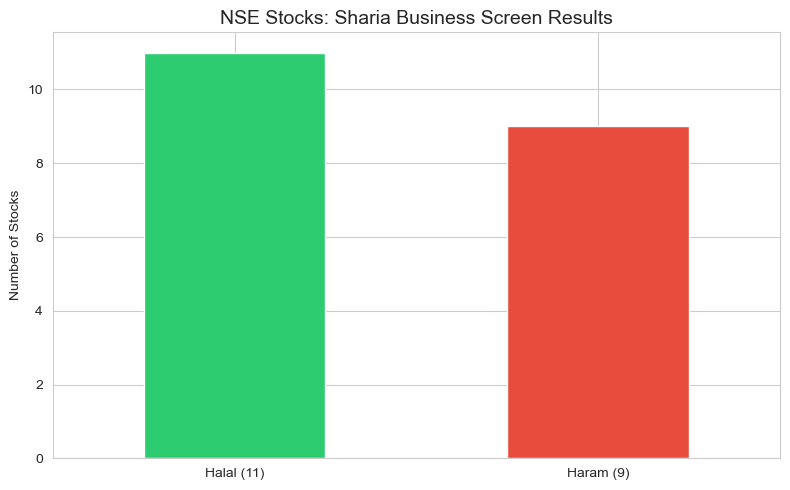

In [78]:
sns.set_style("whitegrid")

screen_counts = stocks['Passes_screen'].value_counts()

plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c']
screen_counts.plot(kind='bar', color=colors)

plt.title('NSE Stocks: Sharia Business Screen Results', fontsize=14)
plt.xlabel('')
plt.ylabel('Number of Stocks')
plt.xticks(ticks=[0, 1], labels=['Halal (11)', 'Haram (9)'], rotation=0)
plt.tight_layout()
plt.savefig(r'C:\Users\siraa\Desktop\nse-sharia-screener\data\screen_results.png', dpi=150)
plt.show()

<Figure size 1200x600 with 0 Axes>

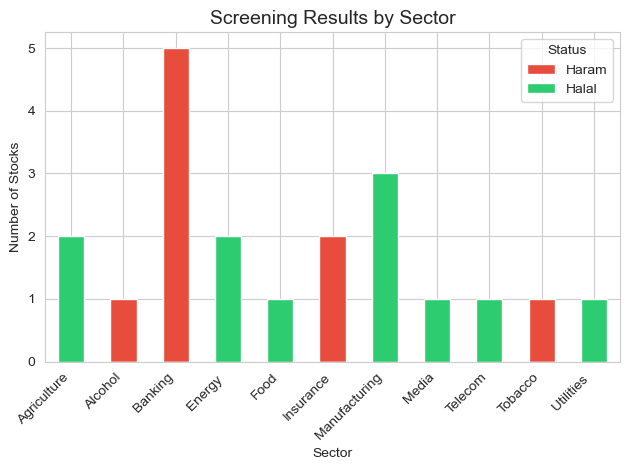

In [79]:
plt.figure(figsize=(12, 6))
sector_counts = stocks.groupby(['Sector', 'Passes_screen']).size().unstack(fill_value=0)

sector_counts.plot(kind='bar', stacked=True, color=['#e74c3c', '#2ecc71'])
plt.title('Screening Results by Sector', fontsize=14)
plt.xlabel('Sector')
plt.ylabel('Number of Stocks')
plt.xticks(rotation=45, ha='right')
plt.legend(['Haram', 'Halal'], title='Status')
plt.tight_layout()
plt.savefig(r'C:\Users\siraa\Desktop\nse-sharia-screener\data\sector_breakdown.png', dpi=150)
plt.show()

## Summary

Out of 20 NSE-listed stocks screened, **11 passed** the Sharia business 
activity screen and **9 were excluded** due to primary business in 
prohibited sectors (banking, insurance, alcohol, tobacco).

### Next steps (v2)
- Add AAOIFI financial ratio screens (debt ratio, interest income ratio)
- Expand stock universe to all NSE-listed companies